# Generate figures for animation of SASSIE domain

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import glob
import warnings
from pathlib import Path
import s3fs
from pprint import pprint
import matplotlib
from matplotlib.backends.backend_pdf import PdfPages
from tqdm import tqdm
import cmocean
import os

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:37995")
client

<Client: 'tcp://127.0.0.1:37995' processes=8 threads=32, memory=123.95 GiB>

### Open 3D model fields

In [3]:
# function to open zarr store with a provided s3 bucket path

def open_zarr_store(s3_path):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(anon=False)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

In [4]:
# open SALT zarr store
salt_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/')

# open THETA zarr store
theta_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/')

# open SEA ICE AREA zarr store
SIarea_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/')

# open SEA ICE AREA zarr store
qnet_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/EXFqnet_AVG_DAILY.ZARR/')

ffmpeg ref: https://trac.ffmpeg.org/wiki/Encode/H.264

To make an animation:

`ffmpeg -r 4 -i figname_%03d.png -pix_fmt yuv420p -vf "scale=trunc(iw/2)*2:trunc(ih/2)*2" filename.mp4`

Break each piece down and explain:

`-r 4`: This sets the frame rate to 4 frames per second (fps). This means that the resulting video will play at 4 frames per second.

`-i figname_%03d.png`:

    -i specifies the input files.
    figname_%03d.png is a pattern that FFmpeg uses to match sequentially numbered PNG files.
        %03d tells FFmpeg to look for numbers in the filenames padded to 3 digits (e.g., figname_001.png, figname_002.png, etc.).

`-pix_fmt yuv420p`: This sets the pixel format to yuv420p, which is widely compatible with video players. It stands for:

    Y (luminance/brightness)
    UV (chrominance/color) at 4:2:0 subsampling, meaning lower color resolution, which is common for video compression.

`-vf "scale=trunc(iw/2)*2:trunc(ih/2)*2"`:

    -vf applies a video filter (in this case, the scale filter).
    "scale=trunc(iw/2)*2:trunc(ih/2)*2" resizes the input video to make sure its width (iw) and height (ih) are even numbers.
        trunc(iw/2)*2 ensures the width is divisible by 2 by truncating the division result and multiplying by 2. Similarly for the height.
        Many codecs require the video dimensions to be divisible by 2 for proper encoding.

`filename.mp4`: This is the name of the output file, which will be encoded as an MP4 video.

We want:
- 4 zero padding in filename to number each day sequentially

`ffmpeg -r 10 -i sassie-ecco-salinity_%04d.png -pix_fmt yuv420p -vf "scale=trunc(iw/2)*2:trunc(ih/2)*2" -crf 10 sassie-ecco-surface-salinity-2020.mp4`

To make the resolution better and video larger:

`ffmpeg -r 10 -i sassie-ecco-salinity_%04d.png -pix_fmt yuv420p -vf "scale=trunc(iw*2/2)*2:trunc(ih*2/2)*2" -crf 10 sassie-ecco-surface-salinity-2020.mp4`

#### Final notes

- using png with dpi = 300 worked well
- 10 frames per second is good speed
- crf 10 seems like good quality
- can adjust scale depending on what size video you want
- I don't think having the flag `-preset slow` is doing anything noticeable...

`ffmpeg -r 10 -i sassie-ecco-salinity_%04d.png -pix_fmt yuv420p -vf "scale=trunc(iw/2)*2:trunc(ih/2)*2" -crf 10 sassie-ecco-surface-salinity-2020.mp4`

## Make figure with SSS and sea ice on top, then same for SST

In [57]:
date = '2019-10-25'

In [58]:
SIarea_ds = (SIarea_zarr.sel(time=date).SIarea*100).load()
salt_ds = salt_zarr.sel(time=date).isel(k=0).SALT.load()
theta_ds = theta_zarr.sel(time=date).isel(k=0).THETA.load()
qnet_ds = (qnet_zarr.sel(time=date).EXFqnet*-1).load() # make qnet positive downward so >0 increases theta

In [59]:
# mask out grid cells where sea ice is < 15%
SIarea_over15 = SIarea_ds.where(SIarea_ds>15,np.nan)
salt_ice_mask = salt_ds.where(SIarea_ds<15,np.nan)
temp_ice_mask = theta_ds.where(SIarea_ds<15,np.nan)
qnet_ice_mask = qnet_ds.where(SIarea_ds<15,np.nan)

In [60]:
salt_flip = xr.DataArray(np.rot90(salt_ice_mask.isel(i=slice(450,700),j=slice(0,500),time=0),3), dims=['i','j'])
temp_flip = xr.DataArray(np.rot90(temp_ice_mask.isel(i=slice(450,700),j=slice(0,500),time=0),3), dims=['i','j'])
si_flip = xr.DataArray(np.rot90(SIarea_over15.isel(i=slice(450,700),j=slice(0,500),time=0),3), dims=['i','j'])
qnet_flip = xr.DataArray(np.rot90(qnet_ice_mask.isel(i=slice(450,700),j=slice(0,500),time=0),3), dims=['i','j'])

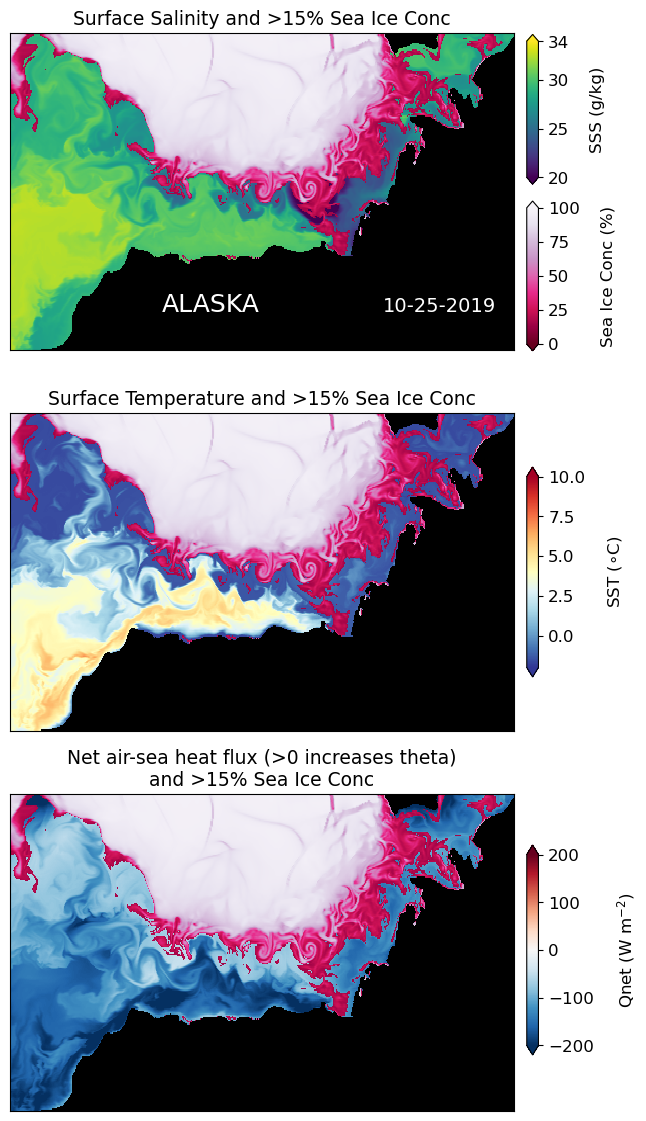

In [61]:
plt.rcParams.update({'font.size': 12})
fig, (ax1,ax2,ax3) = plt.subplots(3,1,figsize=[6.5,14])

# SSS
salt_cmap = salt_flip.plot(ax=ax1,vmin=20,vmax=34,cmap='viridis',add_colorbar=False)
si_cmap = si_flip.plot(ax=ax1,vmin=0,vmax=100,cmap='PuRd_r',add_colorbar=False)
# ax1.set_title("SASSIE ECCO llc1080 Ocean Model\n\nSurface Salinity and >15% Sea Ice Conc",fontsize=13.5);
ax1.set_title("Surface Salinity and >15% Sea Ice Conc",fontsize=13.5);

# SST
temp_cmap = temp_flip.plot(ax=ax2,vmin=-2,vmax=10,cmap='RdYlBu_r',add_colorbar=False)
si_flip.plot(ax=ax2,vmin=0,vmax=100,cmap='PuRd_r',add_colorbar=False)
ax2.set_title("Surface Temperature and >15% Sea Ice Conc",fontsize=13.5);

# qnet
qnet_cmap = qnet_flip.plot(ax=ax3,vmin=-200,vmax=200,cmap='RdBu_r',add_colorbar=False)
si_flip.plot(ax=ax3,vmin=0,vmax=100,cmap='PuRd_r',add_colorbar=False)
ax3.set_title("Net air-sea heat flux (>0 increases theta)\nand >15% Sea Ice Conc",fontsize=13.5);

# add text for date
date_str = str(salt_ds.time.values)
date = date_str[7:10] + date_str[10:12] + '-' + date_str[2:6]
ax1.text(370,30,f'{date}',size=14,color='white')

# # add text for date
# date_str = str(theta_ds.time.values)
# date = date_str[7:10] + date_str[10:12] + '-' + date_str[2:6]
# ax2.text(370,35,f'{date}',size=14,color='white')

# add text for date
# date_str = str(qnet_ds.time.values)
# date = date_str[7:10] + date_str[10:12] + '-' + date_str[2:6]
# ax3.text(370,35,f'{date}',size=14,color='white')

# add text for depth
# ax1.text(370,20,'Z = -0.5 m',size=14,color='white')

# add label for Alaska
ax1.text(150,30,'ALASKA',size=18, color='white')

for ax in (ax1,ax2,ax3):
    # make background black
    ax.set_facecolor('k')

    # remove tick labels
    ax.set_xticklabels([])
    ax.set_yticklabels([]);
    ax.tick_params(left = False, bottom = False) 
    ax.set_xlabel("")
    ax.set_ylabel("");

    # # add text for depth
    # ax.text(370,20,'Z = -0.5 [m]',size=14,color='white')
    
    # # add label for Alaska
    # ax.text(150,30,'ALASKA',size=18, color='white')

# Define the positions of the colorbars (relative to the figure dimensions)
cbar_ax1 = fig.add_axes([0.92, 0.772, 0.018, 0.107])  # [left, bottom, width, height] for the upper colorbar
cbar_ax2 = fig.add_axes([0.92, 0.653, 0.018, 0.107])   # [left, bottom, width, height] for the lower colorbar
cbar_ax3 = fig.add_axes([0.92, 0.42, 0.018, 0.15])   # [left, bottom, width, height] for the lower colorbar
cbar_ax4 = fig.add_axes([0.92, 0.15, 0.018, 0.15])   # [left, bottom, width, height] for the lower colorbar

# Create the colorbars
cbar1 = fig.colorbar(salt_cmap, cax=cbar_ax1, extend='both')
cbar1.set_label("SSS (g/kg)", rotation=90, labelpad=15)
cbar1.set_ticks([20, 25, 30, 34])

cbar2 = fig.colorbar(si_cmap, cax=cbar_ax2, extend='both')
cbar2.set_label("Sea Ice Conc (%)", rotation=90, labelpad=15)

cbar3 = fig.colorbar(temp_cmap, cax=cbar_ax3, extend='both')
cbar3.set_label("SST ($\circ$C)", rotation=90, labelpad=15)

cbar4 = fig.colorbar(qnet_cmap, cax=cbar_ax4, extend='both')
cbar4.set_label("Qnet (W m$^{-2}$)", rotation=90, labelpad=15)

plt.savefig("/home/jpluser/git_repos/SASSIE_ECCO_salinity_stratification/figures/Icebridge_snapshot_20191025.png",dpi=300,bbox_inches='tight')

***

## Generate series of PNG images, one for each day

In [65]:
time_start = "2020-01-01"
time_end = "2020-12-31"
k_level = 0

In [66]:
seaice_da = SIarea_zarr.sel(time=slice(time_start,time_end)).SIarea*100
salt_da = salt_zarr.sel(time=slice(time_start,time_end)).isel(k=k_level).SALT
temp_da = theta_zarr.sel(time=slice(time_start,time_end)).isel(k=k_level).THETA
qnet_da = qnet_zarr.sel(time=slice(time_start,time_end)).EXFqnet

In [67]:
# mask out grid cells where sea ice is < 15%
SIarea_over15 = seaice_da.where(seaice_da>15,np.nan)
salt_ice_mask = salt_da.where(seaice_da<15,np.nan)
temp_ice_mask = temp_da.where(seaice_da<15,np.nan)
qnet_ice_mask = qnet_da.where(seaice_da<15,np.nan)

In [68]:
# rotate 90 degrees counterclockwise
salt_flip = xr.DataArray(np.rot90(salt_ice_mask.isel(i=slice(450,700),j=slice(0,500)),3,axes=[1,2]), dims=['time','i','j'])
temp_flip = xr.DataArray(np.rot90(temp_ice_mask.isel(i=slice(450,700),j=slice(0,500)),3,axes=[1,2]), dims=['time','i','j'])
si_flip = xr.DataArray(np.rot90(SIarea_over15.isel(i=slice(450,700),j=slice(0,500)),3,axes=[1,2]), dims=['time','i','j'])
qnet_flip = xr.DataArray(np.rot90(qnet_ice_mask.isel(i=slice(450,700),j=slice(0,500)),3,axes=[1,2]), dims=['time','i','j'])

In [70]:
for i in tqdm(range(len(seaice_da.time))):
    
    # pull out one day
    salt_day_da = salt_flip.isel(time=i)
    temp_day_da = temp_flip.isel(time=i)
    seaice_day_da = si_flip.isel(time=i)
    qnet_day_da = qnet_flip.isel(time=i)
    
    # make plot
    plt.rcParams.update({'font.size': 13})
    fig, (ax1,ax2,ax3) = plt.subplots(3,1,figsize=[6.5,14])
    
    # SSS
    salt_cmap = salt_day_da.plot(ax=ax1,vmin=20,vmax=36,cmap='viridis_r',add_colorbar=False)
    si_cmap = seaice_day_da.plot(ax=ax1,vmin=0,vmax=100,cmap='PuRd_r',add_colorbar=False)
    ax1.set_title("SASSIE ECCO llc1080 Ocean Model\n\nSurface Salinity and >15% Sea Ice Conc",fontsize=13.5);

    # SST
    temp_cmap = temp_day_da.plot(ax=ax2,vmin=-2,vmax=10,cmap='RdYlBu_r',add_colorbar=False)
    seaice_day_da.plot(ax=ax2,vmin=0,vmax=100,cmap='PuRd_r',add_colorbar=False)
    ax2.set_title("Surface Temperature and >15% Sea Ice Conc",fontsize=13.5);

    # qnet
    qnet_cmap = qnet_day_da.plot(ax=ax3,vmin=-200,vmax=200,cmap='RdBu_r',add_colorbar=False)
    seaice_day_da.plot(ax=ax3,vmin=0,vmax=100,cmap='PuRd_r',add_colorbar=False)
    ax3.set_title("Net air-sea heat flux (>0 decreases theta)\nand >15% Sea Ice Conc",fontsize=13.5);

    # add text for date
    date_str = str(seaice_da.time[i].values)
    date = date_str[5:10] + '-' + date_str[0:4]
    ax1.text(370,35,f'{date}',size=14,color='white')

    # add text for depth
    ax1.text(370,20,'Z = -0.5 [m]',size=14,color='white')

    # add label for Alaska
    ax1.text(150,30,'ALASKA',size=18, color='white')

    for ax in (ax1,ax2,ax3):
        # make background black
        ax.set_facecolor('k')
    
        # remove tick labels
        ax.set_xticklabels([])
        ax.set_yticklabels([]);
        ax.tick_params(left = False, bottom = False) 
        ax.set_xlabel("")
        ax.set_ylabel("");

    # Define the positions of the colorbars (relative to the figure dimensions)
    cbar_ax1 = fig.add_axes([0.92, 0.772, 0.018, 0.107])  # [left, bottom, width, height] for the upper colorbar
    cbar_ax2 = fig.add_axes([0.92, 0.653, 0.018, 0.107])   # [left, bottom, width, height] for the lower colorbar
    cbar_ax3 = fig.add_axes([0.92, 0.42, 0.018, 0.15])   # [left, bottom, width, height] for the lower colorbar
    cbar_ax4 = fig.add_axes([0.92, 0.15, 0.018, 0.15])   # [left, bottom, width, height] for the lower colorbar
    
    # Create the colorbars
    cbar1 = fig.colorbar(salt_cmap, cax=cbar_ax1, extend='both')
    cbar1.set_label("SSS (g/kg)", rotation=90, labelpad=15)
    
    cbar2 = fig.colorbar(si_cmap, cax=cbar_ax2, extend='both')
    cbar2.set_label("Sea Ice Conc (%)", rotation=90, labelpad=15)
    
    cbar3 = fig.colorbar(temp_cmap, cax=cbar_ax3, extend='both')
    cbar3.set_label("SST ($\circ$C)", rotation=90, labelpad=15)

    cbar4 = fig.colorbar(qnet_cmap, cax=cbar_ax4, extend='both')
    cbar4.set_label("Qnet (W m$^{-2}$)", rotation=90, labelpad=15)
    
    # save fig
    filename = f"sassie-ecco-seaice-sss-sst-beaufort-{date[-4:]}_{i:04d}.png"
    plt.savefig(f"/home/jpluser/efs-mount-point/mzahn/sassie/HH/animation/pngs/{filename}",dpi=300,bbox_inches='tight')
    
    plt.close()
    
    # print(f'. . . saved {filename}')

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 366/366 [11:02<00:00,  1.81s/it]


#### Run in terminal:

For salinity and sea ice movie:<br>
`ffmpeg -r 10 -i sassie-ecco-seaice-sss-sst-beaufort-2020_%04d.png -pix_fmt yuv420p -vf "scale=trunc(iw/2)*2:trunc(ih/2)*2" -crf 10 sassie-ecco-seaice-sss-sst-qnet-beaufort-2020.mp4`

transfer to ecco s3 bucket:<br>
`aws s3 cp ~/efs-mount-point/mzahn/sassie/HH/animation/pngs/sassie-ecco-seaice-sss-sst-qnet-beaufort-2020.mp4 s3://ecco-processed-data/SASSIE/Videos/`

transfer to ecco s3 bucket:<br>
`aws s3 cp ~/efs-mount-point/mzahn/sassie/HH/animation/pngs/2014/sassie-ecco-seaice-sss-sst-qnet-beaufort-2014.mp4 s3://ecco-processed-data/SASSIE/Videos/`

## Master loop to generate movies for each year

In [5]:
# Loop through each year from 2014 to 2020
# for year in range(2014, 2021):
for year in range(2019, 2021):

    # Set time range for the year
    time_start = f"{year}-01-01"
    time_end = f"{year}-12-31"
    k_level = 0

    # Load datasets
    seaice_da = SIarea_zarr.sel(time=slice(time_start, time_end)).SIarea * 100
    salt_da = salt_zarr.sel(time=slice(time_start, time_end)).isel(k=k_level).SALT
    temp_da = theta_zarr.sel(time=slice(time_start, time_end)).isel(k=k_level).THETA
    qnet_da = qnet_zarr.sel(time=slice(time_start, time_end)).EXFqnet

    # Mask out grid cells where sea ice is < 15%
    SIarea_over15 = seaice_da.where(seaice_da > 15, np.nan)
    salt_ice_mask = salt_da.where(seaice_da < 15, np.nan)
    temp_ice_mask = temp_da.where(seaice_da < 15, np.nan)
    qnet_ice_mask = qnet_da.where(seaice_da < 15, np.nan)

    # Rotate 90 degrees counterclockwise
    salt_flip = xr.DataArray(np.rot90(salt_ice_mask.isel(i=slice(450, 700), j=slice(0, 500)), 3, axes=[1, 2]), dims=['time', 'i', 'j'])
    temp_flip = xr.DataArray(np.rot90(temp_ice_mask.isel(i=slice(450, 700), j=slice(0, 500)), 3, axes=[1, 2]), dims=['time', 'i', 'j'])
    si_flip = xr.DataArray(np.rot90(SIarea_over15.isel(i=slice(450, 700), j=slice(0, 500)), 3, axes=[1, 2]), dims=['time', 'i', 'j'])
    qnet_flip = xr.DataArray(np.rot90(qnet_ice_mask.isel(i=slice(450, 700), j=slice(0, 500)), 3, axes=[1, 2]), dims=['time', 'i', 'j'])

    # Output directory
    output_dir = f"/home/jpluser/efs-mount-point/mzahn/sassie/HH/animation/pngs/{year}/"
    os.makedirs(output_dir, exist_ok=True)

    for i in tqdm(range(len(seaice_da.time))):

        # Extract data for the day
        salt_day_da = salt_flip.isel(time=i)
        temp_day_da = temp_flip.isel(time=i)
        seaice_day_da = si_flip.isel(time=i)
        qnet_day_da = qnet_flip.isel(time=i)

        # Create plot
        plt.rcParams.update({'font.size': 13})
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=[6.5, 14])

        # SSS
        salt_cmap = salt_day_da.plot(ax=ax1, vmin=20, vmax=36, cmap='viridis_r', add_colorbar=False)
        si_cmap = seaice_day_da.plot(ax=ax1, vmin=0, vmax=100, cmap='PuRd_r', add_colorbar=False)
        ax1.set_title("SASSIE ECCO llc1080 Ocean Model\n\nSurface Salinity and >15% Sea Ice Conc", fontsize=13.5)

        # SST
        temp_cmap = temp_day_da.plot(ax=ax2, vmin=-2, vmax=10, cmap='RdYlBu_r', add_colorbar=False)
        seaice_day_da.plot(ax=ax2, vmin=0, vmax=100, cmap='PuRd_r', add_colorbar=False)
        ax2.set_title("Surface Temperature and >15% Sea Ice Conc", fontsize=13.5)

        # qnet
        qnet_cmap = qnet_day_da.plot(ax=ax3, vmin=-200, vmax=200, cmap='RdBu_r', add_colorbar=False)
        seaice_day_da.plot(ax=ax3, vmin=0, vmax=100, cmap='PuRd_r', add_colorbar=False)
        ax3.set_title("Net air-sea heat flux (>0 decreases theta)\nand >15% Sea Ice Conc", fontsize=13.5)

        # Add text for date
        date_str = str(seaice_da.time[i].values)
        date = date_str[5:10] + '-' + date_str[0:4]
        ax1.text(370, 35, f'{date}', size=14, color='white')

        # Add depth, labels, and style
        ax1.text(370, 20, 'Z = -0.5 [m]', size=14, color='white')
        ax1.text(150, 30, 'ALASKA', size=18, color='white')

        for ax in (ax1, ax2, ax3):
            ax.set_facecolor('k')
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.tick_params(left=False, bottom=False)
            ax.set_xlabel("")
            ax.set_ylabel("")

        # Define colorbars
        cbar_ax1 = fig.add_axes([0.92, 0.772, 0.018, 0.107])
        cbar_ax2 = fig.add_axes([0.92, 0.653, 0.018, 0.107])
        cbar_ax3 = fig.add_axes([0.92, 0.42, 0.018, 0.15])
        cbar_ax4 = fig.add_axes([0.92, 0.15, 0.018, 0.15])

        # Add colorbars
        fig.colorbar(salt_cmap, cax=cbar_ax1, extend='both').set_label("SSS (g/kg)", rotation=90, labelpad=15)
        fig.colorbar(si_cmap, cax=cbar_ax2, extend='both').set_label("Sea Ice Conc (%)", rotation=90, labelpad=15)
        fig.colorbar(temp_cmap, cax=cbar_ax3, extend='both').set_label("SST ($\\circ$C)", rotation=90, labelpad=15)
        fig.colorbar(qnet_cmap, cax=cbar_ax4, extend='both').set_label("Qnet (W m$^{-2}$)", rotation=90, labelpad=15)

        # Save figure
        filename = f"sassie-ecco-seaice-sss-sst-qnet-beaufort-{year}_{i:04d}.png"
        plt.savefig(f"{output_dir}/{filename}", dpi=300, bbox_inches='tight')
        plt.close()

    # Generate movie using ffmpeg
    print(f"ffmpeg -r 10 -i {output_dir}sassie-ecco-seaice-sss-sst-qnet-beaufort-{year}_%04d.png -pix_fmt yuv420p -vf \"scale=trunc(iw/2)*2:trunc(ih/2)*2\" -crf 10 {output_dir}sassie-ecco-seaice-sss-sst-qnet-beaufort-{year}.mp4")
    os.system(f"ffmpeg -r 10 -i {output_dir}sassie-ecco-seaice-sss-sst-qnet-beaufort-{year}_%04d.png -pix_fmt yuv420p -vf \"scale=trunc(iw/2)*2:trunc(ih/2)*2\" -crf 10 {output_dir}sassie-ecco-seaice-sss-sst-qnet-beaufort-{year}.mp4")

    # Upload to AWS S3
    print(f"aws s3 cp {output_dir}sassie-ecco-seaice-sss-sst-qnet-beaufort-{year}.mp4 s3://ecco-processed-data/SASSIE/Videos/")
    os.system(f"aws s3 cp {output_dir}sassie-ecco-seaice-sss-sst-qnet-beaufort-{year}.mp4 s3://ecco-processed-data/SASSIE/Videos/")

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 365/365 [11:09<00:00,  1.83s/it]
ffmpeg version N-71064-gd5e603ddc0-static https://johnvansickle.com/ffmpeg/  Copyright (c) 2000-2024 the FFmpeg developers
  built with gcc 8 (Debian 8.3.0-6)
  configuration: --enable-gpl --enable-version3 --enable-static --disable-debug --disable-ffplay --disable-indev=sndio --disable-outdev=sndio --cc=gcc --enable-fontconfig --enable-frei0r --enable-gnutls --enable-gmp --enable-libgme --enable-gray --enable-libaom --enable-libfribidi --enable-libass --enable-libvmaf --enable-libfreetype --enable-libmp3lame --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-librubberband --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libvorbis --enable-libopus --enable-libtheora --enable-libvidstab --enable-libvo-amrwbenc --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265

ffmpeg -r 10 -i /home/jpluser/efs-mount-point/mzahn/sassie/HH/animation/pngs/2019/sassie-ecco-seaice-sss-sst-qnet-beaufort-2019_%04d.png -pix_fmt yuv420p -vf "scale=trunc(iw/2)*2:trunc(ih/2)*2" -crf 10 /home/jpluser/efs-mount-point/mzahn/sassie/HH/animation/pngs/2019/sassie-ecco-seaice-sss-sst-qnet-beaufort-2019.mp4


Input #0, image2, from '/home/jpluser/efs-mount-point/mzahn/sassie/HH/animation/pngs/2019/sassie-ecco-seaice-sss-sst-qnet-beaufort-2019_%04d.png':
  Duration: 00:00:14.60, start: 0.000000, bitrate: N/A
  Stream #0:0: Video: png, rgba(pc, gbr/unknown/unknown), 1944x3489 [SAR 11811:11811 DAR 648:1163], 25 fps, 25 tbr, 25 tbn
Stream mapping:
  Stream #0:0 -> #0:0 (png (native) -> h264 (libx264))
Press [q] to stop, [?] for help
[libx264 @ 0x80d9a80] using SAR=3488/3489
[libx264 @ 0x80d9a80] using cpu capabilities: MMX2 SSE2Fast SSSE3 SSE4.2 AVX FMA3 BMI2 AVX2 AVX512
[libx264 @ 0x80d9a80] profile High, level 5.1, 4:2:0, 8-bit
[libx264 @ 0x80d9a80] 264 - core 164 r3191 4613ac3 - H.264/MPEG-4 AVC codec - Copyleft 2003-2024 - http://www.videolan.org/x264.html - options: cabac=1 ref=3 deblock=1:0:0 analyse=0x3:0x113 me=hex subme=7 psy=1 psy_rd=1.00:0.00 mixed_ref=1 me_range=16 chroma_me=1 trellis=1 8x8dct=1 cqm=0 deadzone=21,11 fast_pskip=1 chroma_qp_offset=-2 threads=48 lookahead_threads=8 sli

aws s3 cp /home/jpluser/efs-mount-point/mzahn/sassie/HH/animation/pngs/2019/sassie-ecco-seaice-sss-sst-qnet-beaufort-2019.mp4 s3://ecco-processed-data/SASSIE/Videos/
upload: ../../../../efs-mount-point/mzahn/sassie/HH/animation/pngs/2019/sassie-ecco-seaice-sss-sst-qnet-beaufort-2019.mp4 to s3://ecco-processed-data/SASSIE/Videos/sassie-ecco-seaice-sss-sst-qnet-beaufort-2019.mp4


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 366/366 [11:02<00:00,  1.81s/it]
ffmpeg version N-71064-gd5e603ddc0-static https://johnvansickle.com/ffmpeg/  Copyright (c) 2000-2024 the FFmpeg developers
  built with gcc 8 (Debian 8.3.0-6)
  configuration: --enable-gpl --enable-version3 --enable-static --disable-debug --disable-ffplay --disable-indev=sndio --disable-outdev=sndio --cc=gcc --enable-fontconfig --enable-frei0r --enable-gnutls --enable-gmp --enable-libgme --enable-gray --enable-libaom --enable-libfribidi --enable-libass --enable-libvmaf --enable-libfreetype --enable-libmp3lame --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-librubberband --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libvorbis --enable-libopus --enable-libtheora --enable-libvidstab --enable-libvo-amrwbenc --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265

ffmpeg -r 10 -i /home/jpluser/efs-mount-point/mzahn/sassie/HH/animation/pngs/2020/sassie-ecco-seaice-sss-sst-qnet-beaufort-2020_%04d.png -pix_fmt yuv420p -vf "scale=trunc(iw/2)*2:trunc(ih/2)*2" -crf 10 /home/jpluser/efs-mount-point/mzahn/sassie/HH/animation/pngs/2020/sassie-ecco-seaice-sss-sst-qnet-beaufort-2020.mp4


[libx264 @ 0x79ad040] using SAR=3488/3489
[libx264 @ 0x79ad040] using cpu capabilities: MMX2 SSE2Fast SSSE3 SSE4.2 AVX FMA3 BMI2 AVX2 AVX512
[libx264 @ 0x79ad040] profile High, level 5.1, 4:2:0, 8-bit
[libx264 @ 0x79ad040] 264 - core 164 r3191 4613ac3 - H.264/MPEG-4 AVC codec - Copyleft 2003-2024 - http://www.videolan.org/x264.html - options: cabac=1 ref=3 deblock=1:0:0 analyse=0x3:0x113 me=hex subme=7 psy=1 psy_rd=1.00:0.00 mixed_ref=1 me_range=16 chroma_me=1 trellis=1 8x8dct=1 cqm=0 deadzone=21,11 fast_pskip=1 chroma_qp_offset=-2 threads=48 lookahead_threads=8 sliced_threads=0 nr=0 decimate=1 interlaced=0 bluray_compat=0 constrained_intra=0 bframes=3 b_pyramid=2 b_adapt=1 b_bias=0 direct=1 weightb=1 open_gop=0 weightp=2 keyint=250 keyint_min=10 scenecut=40 intra_refresh=0 rc_lookahead=40 rc=crf mbtree=1 crf=10.0 qcomp=0.60 qpmin=0 qpmax=69 qpstep=4 ip_ratio=1.40 aq=1:1.00
Output #0, mp4, to '/home/jpluser/efs-mount-point/mzahn/sassie/HH/animation/pngs/2020/sassie-ecco-seaice-sss-sst-

aws s3 cp /home/jpluser/efs-mount-point/mzahn/sassie/HH/animation/pngs/2020/sassie-ecco-seaice-sss-sst-qnet-beaufort-2020.mp4 s3://ecco-processed-data/SASSIE/Videos/
upload: ../../../../efs-mount-point/mzahn/sassie/HH/animation/pngs/2020/sassie-ecco-seaice-sss-sst-qnet-beaufort-2020.mp4 to s3://ecco-processed-data/SASSIE/Videos/sassie-ecco-seaice-sss-sst-qnet-beaufort-2020.mp4
